# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [12]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

# TODO: đặt BATCH_SIZE, EPOCHS, LEARNING_RATE, DATA_DIR
BATCH_SIZE = 256
EPOCHS = 5
LEARNING_RATE = 1e-3
DATA_DIR = ""

# TODO: chọn DEVICE là 'cuda' nếu torch.cuda.is_available(), ngược lại 'cpu'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(0)
print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')

PyTorch: 2.13.0+cu126
Thiết bị: cuda


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

full_train = datasets.EMNIST(DATA_DIR, split='letters', train=True, transform=transform, download=True)
test_set = datasets.EMNIST(DATA_DIR, split='letters', train=False, transform=transform, download=True)

# TODO: dùng random_split tách full_train thành train_set (100.000) và val_set (24.800)
train_set, val_set = random_split(full_train, [100000, 24800])
# TODO: tạo train_loader, val_loader, test_loader với batch_size=BATCH_SIZE

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(len(train_set), len(val_set), len(test_set))

100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


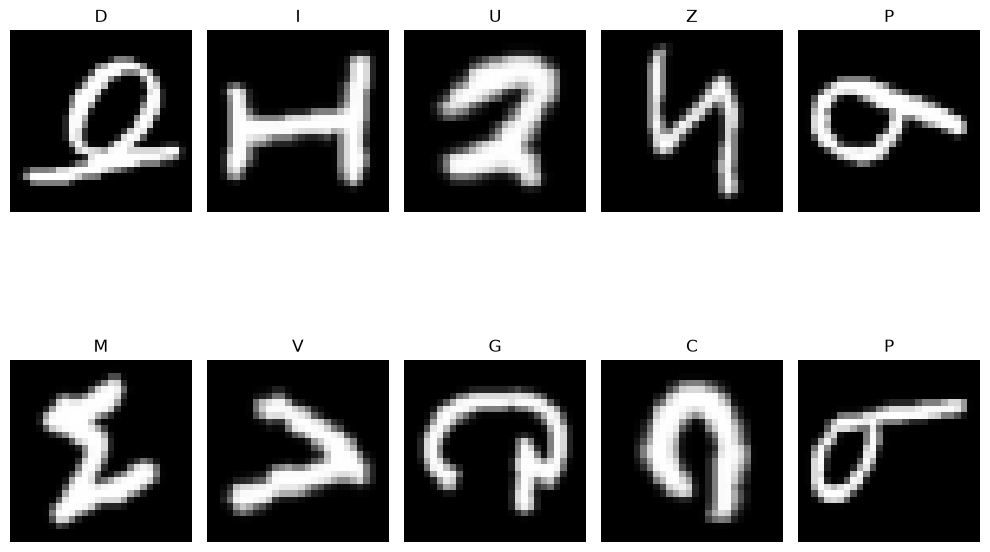

In [14]:
batch_images, batch_labels = next(iter(train_loader))
print('Batch ảnh :', batch_images.shape)
print('Batch nhãn:', batch_labels.shape)

# TODO: vẽ 10 ảnh đầu tiên của batch (cmap='gray'), tiêu đề mỗi ảnh là nhãn dạng chữ cái
# Lấy 10 ảnh đầu tiên
fig, axes = plt.subplots(2, 5, figsize=(10, 8))

for i, axe in enumerate(axes.flat):
    image = batch_images[i].squeeze().cpu().numpy()
    label = chr(batch_labels[i] + ord('A') - 1)

    axe.imshow(image, cmap="gray")
    axe.set_title(label)
    axe.axis("off")
plt.tight_layout()
plt.show()


## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [15]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 26)
        

    def forward(self, images):
        x = self.flat(images)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        return x
        

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=26, bias=True)
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [16]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    # TODO: lặp qua các batch, cập nhật trọng số, cộng dồn loss và số dự đoán đúng
    # Gợi ý: số dự đoán đúng = (logits.argmax(dim=1) == labels).sum().item()
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE) - 1

        logits = model(images)

        loss = criterion(logits, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size

        total_correct += (logits.argmax(dim=1) == labels).sum().item()

        total_samples += batch_size


    return total_loss / total_samples, total_correct / total_samples

def evaluate(model, loader, criterion):
    model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE) - 1

            logits = model(images)

            loss = criterion(logits, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size

            total_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()

            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [17]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    # TODO: gọi train_one_epoch và evaluate, lưu kết quả vào 4 list
    train_loss, train_accuracy = train_one_epoch(model, train_loader,criterion, optimizer)
    val_loss, val_accuracy = evaluate(model, val_loader,criterion)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy) 
    val_accuracies.append(val_accuracy)
    # TODO: in dạng: Epoch {epoch}: train loss=..., val loss=..., train acc=..., val acc=...
    print(f"Epoch {epoch}: train loss={train_loss}, val loss={val_loss}, train acc={train_accuracy}, val acc={val_accuracy}")

Epoch 1: train loss=1.2334267061042785, val loss=0.8671664126457707, train acc=0.66306, val acc=0.7539516129032258
Epoch 2: train loss=0.7317597815132141, val loss=0.6604673367161905, train acc=0.79088, val acc=0.8078225806451613
Epoch 3: train loss=0.5754687857437134, val loss=0.5511928901364727, train acc=0.83352, val acc=0.8375
Epoch 4: train loss=0.4918146439933777, val loss=0.48905906408063826, train acc=0.8553, val acc=0.854758064516129
Epoch 5: train loss=0.4391930940818787, val loss=0.45611284763582294, train acc=0.86889, val acc=0.862741935483871


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

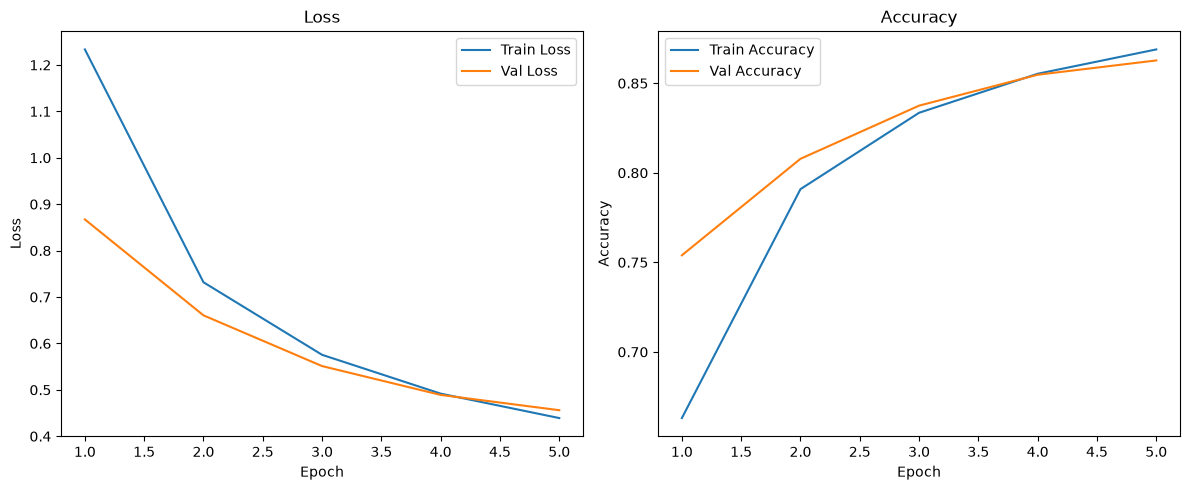

Test loss=0.4639, test accuracy=86.17%


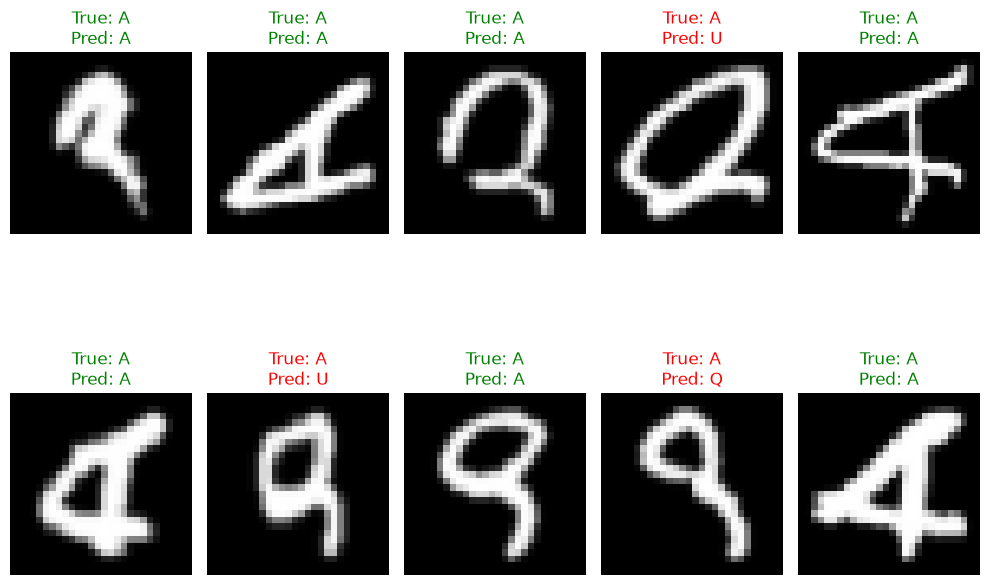

In [18]:
# TODO: vẽ đồ thị Loss và Accuracy theo epoch (train vs val)
x = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss
axes[0].plot(x, train_losses, label="Train Loss")
axes[0].plot(x, val_losses, label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(x, train_accuracies, label="Train Accuracy")
axes[1].plot(x, val_accuracies, label="Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# TODO: lấy 1 batch từ test_loader và vẽ 10 ảnh kèm nhãn thật + nhãn dự đoán

test_loss, test_accuracy = evaluate(model, test_loader, criterion)

print(f"Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}")

# Lấy 1 batch test
batch_images, batch_labels = next(iter(test_loader))

model.eval()

with torch.no_grad():
    logits = model(batch_images.to(DEVICE))

    # Prediction của model là 0-25
    predictions = logits.argmax(dim=1).cpu()


# Vẽ 10 ảnh
fig, axes = plt.subplots(2, 5, figsize=(10, 8))

for i, axe in enumerate(axes.flat):

    image = batch_images[i].squeeze().cpu().numpy()

    # Label gốc của EMNIST: 1-26
    true_label = chr(batch_labels[i].item() + ord('A') - 1)

    # Prediction của model: 0-25
    pred_label = chr(predictions[i].item() + ord('A'))

    # So sánh phải đổi true label từ 1-26 -> 0-25
    correct = (batch_labels[i].item() - 1) == predictions[i].item()

    axe.imshow(image, cmap="gray")

    axe.set_title(
        f"True: {true_label}\nPred: {pred_label}",
        color="green" if correct else "red"
    )

    axe.axis("off")

plt.tight_layout()
plt.show()




## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [19]:
# TODO: lưu state_dict của model vào file 'emnist_mlp.pt'
torch.save(model.state_dict(), "emnist_mlp.pt")